# MLP Baseline

## 1. Imports

In [1]:
from pathlib import Path
import csv
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import GroupKFold
from IPython.display import display


## 2. Configuration


In [2]:
DATASET_MODE = "default"  # or "flopoco" for one-off AST-only run
DATA_PATH = Path("../data/merged_vector_dataset.csv")
RESULTS_ROOT = Path("../results/mlp")
if DATASET_MODE == "flopoco":
    DATA_PATH = Path("../data/merged_vector_dataset_flopoco.csv")
    RESULTS_ROOT = Path("../results/mlp_flopoco")
NUM_FOLDS = 5
USE_FIXED_SEED = True
RANDOM_SEED = 11
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LOSS_NAME = "mse"
# LOSS_NAME = "smooth_l1"
SMOOTH_L1_BETA = 1.0
EPOCHS = 400
HIDDEN_DIM_1 = 64
HIDDEN_DIM_2 = 32
DROPOUT = 0.1

AST_FEATURE_COLUMNS = [
    "total_input_bits",
    "total_output_bits",
    "total_register_bits",
    "total_logic_operator_bits",
    "total_adder_sub_bits",
    "total_multiplier_bits",
    "total_comparator_bits",
    "total_multiplexer_bits",
    "total_shift_bits",
    "total_division_bits",
    "total_memory_write_addr_bits",
    "total_memory_write_addr_width",
    "total_memory_read_addr_bits",
    "total_memory_read_addr_width",
    "average_tree_depth",
    "average_wire_width",
]

NUMERIC_CONFIG_COLUMNS = [
    "clock_period_ns_cfg",
    "max_fanout_cfg",
    "max_transition_ns_cfg",
    "max_capacitance_ff_cfg",
    "fanout_load_cfg",
]

CATEGORICAL_CONFIG_COLUMNS = ["abc_fast_cfg", "flow_mode"]
if DATASET_MODE == "flopoco":
    NUMERIC_CONFIG_COLUMNS = []
    CATEGORICAL_CONFIG_COLUMNS = []
TARGET_COLUMNS = ["worst_slack_ns", "total_negative_slack_ns"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Dataset mode:", DATASET_MODE)

if USE_FIXED_SEED:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)
    print("Using fixed random seed:", RANDOM_SEED)
else:
    print("Using non-deterministic random behavior")

valid_loss_names = {"mse", "smooth_l1"}
if LOSS_NAME not in valid_loss_names:
    raise ValueError(f"LOSS_NAME must be one of {sorted(valid_loss_names)}")
print("Training loss:", LOSS_NAME)


Using device: cpu
Dataset mode: default
Using fixed random seed: 11
Training loss: mse


## 3. Data Loading


In [3]:
with DATA_PATH.open("r", newline="") as f:
    rows = list(csv.DictReader(f))

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
run_num = 1
while True:
    RUN_DIR = RESULTS_ROOT / f"run_{run_num:03d}"
    if not RUN_DIR.exists():
        RUN_DIR.mkdir()
        break
    run_num += 1

rows_df = pd.DataFrame(rows)
AST_FEATURE_COLUMNS = [
    col for col in AST_FEATURE_COLUMNS
    if col in rows_df.columns and rows_df[col].astype(str).str.strip().ne("").any()
]
if not AST_FEATURE_COLUMNS:
    raise ValueError("No AST feature columns were found in the merged dataset.")

print(f"Loaded {len(rows)} rows from {DATA_PATH}")
print(f"Using AST feature columns: {AST_FEATURE_COLUMNS}")
print(f"Saving run artifacts to {RUN_DIR.resolve()}")
rows[:2]



Loaded 13536 rows from ..\data\merged_vector_dataset.csv
Using AST feature columns: ['total_input_bits', 'total_output_bits', 'total_register_bits', 'total_logic_operator_bits', 'total_adder_sub_bits', 'total_multiplier_bits', 'total_comparator_bits', 'total_multiplexer_bits', 'total_shift_bits', 'total_division_bits', 'total_memory_write_addr_bits', 'total_memory_write_addr_width', 'total_memory_read_addr_bits', 'total_memory_read_addr_width', 'average_tree_depth', 'average_wire_width']
Saving run artifacts to C:\Users\DeAndre\Documents\Spring 2026\nndl\final_project\PPA-Estimation-Project\modeling\results\mlp\run_085


[{'design_name': 'i2c',
  'design_id': 'iwls05_0006',
  'recipe_id': 'abcfast_clk0p1_fo16_tr0p16_cap100_fload1',
  'flow_mode': 'full',
  'total_input_bits': '19',
  'total_output_bits': '14',
  'total_register_bits': '128',
  'total_logic_operator_bits': '186',
  'total_adder_sub_bits': '19',
  'total_multiplier_bits': '0',
  'total_comparator_bits': '1350',
  'total_multiplexer_bits': '514',
  'total_shift_bits': '0',
  'total_division_bits': '0',
  'total_memory_write_addr_bits': '0',
  'total_memory_write_addr_width': '0',
  'total_memory_read_addr_bits': '0',
  'total_memory_read_addr_width': '0',
  'average_tree_depth': '6.401617250673854',
  'average_wire_width': '4.707949790794979',
  'worst_slack_ns': '-0.380054',
  'total_negative_slack_ns': '-31.437371',
  'run_utc': '2026-04-06T14:32:37+00:00',
  'run_id': 'i2c__abcfast_clk0p1_fo16_tr0p16_cap100_fload1',
  'top_module': 'i2c_master_top',
  'clock_port': 'wb_clk_i',
  'abc_fast_cfg': 'True',
  'clock_period_ns_cfg': '0.1',
 

## 3.1 Design Feature Outlier View


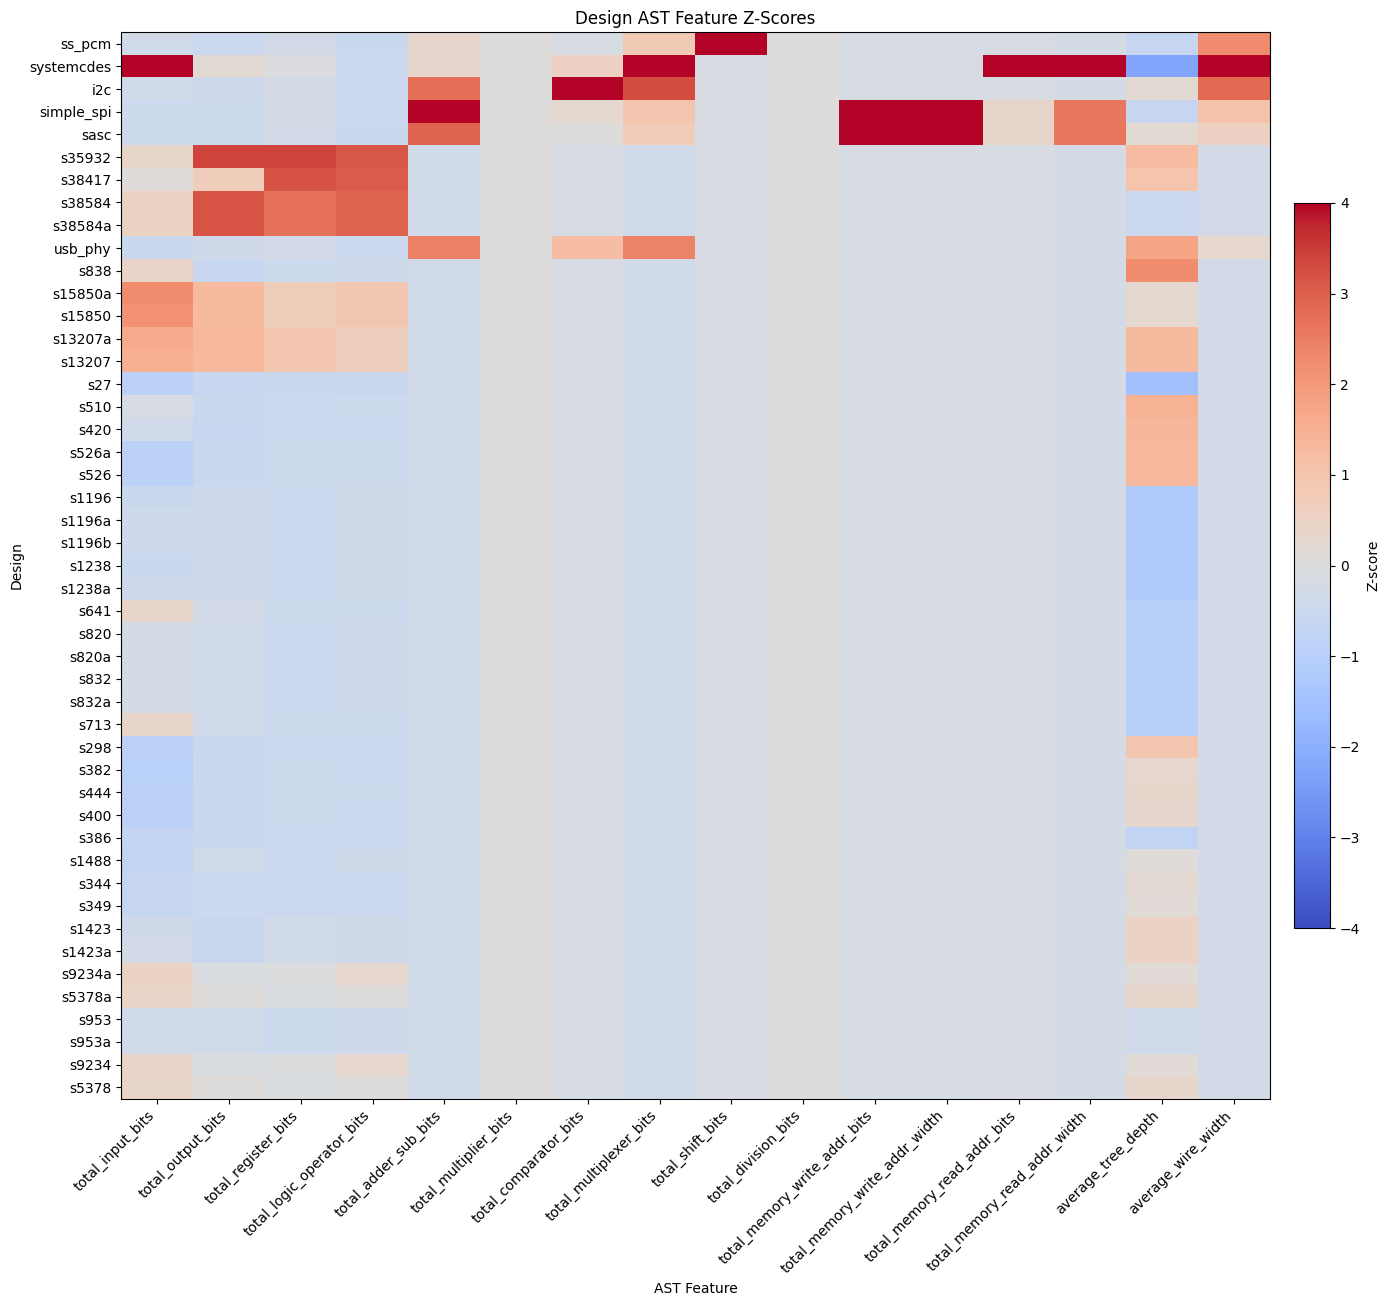

Saved design feature z-score heatmap to ..\results\mlp\run_085\design_feature_zscore_heatmap.png


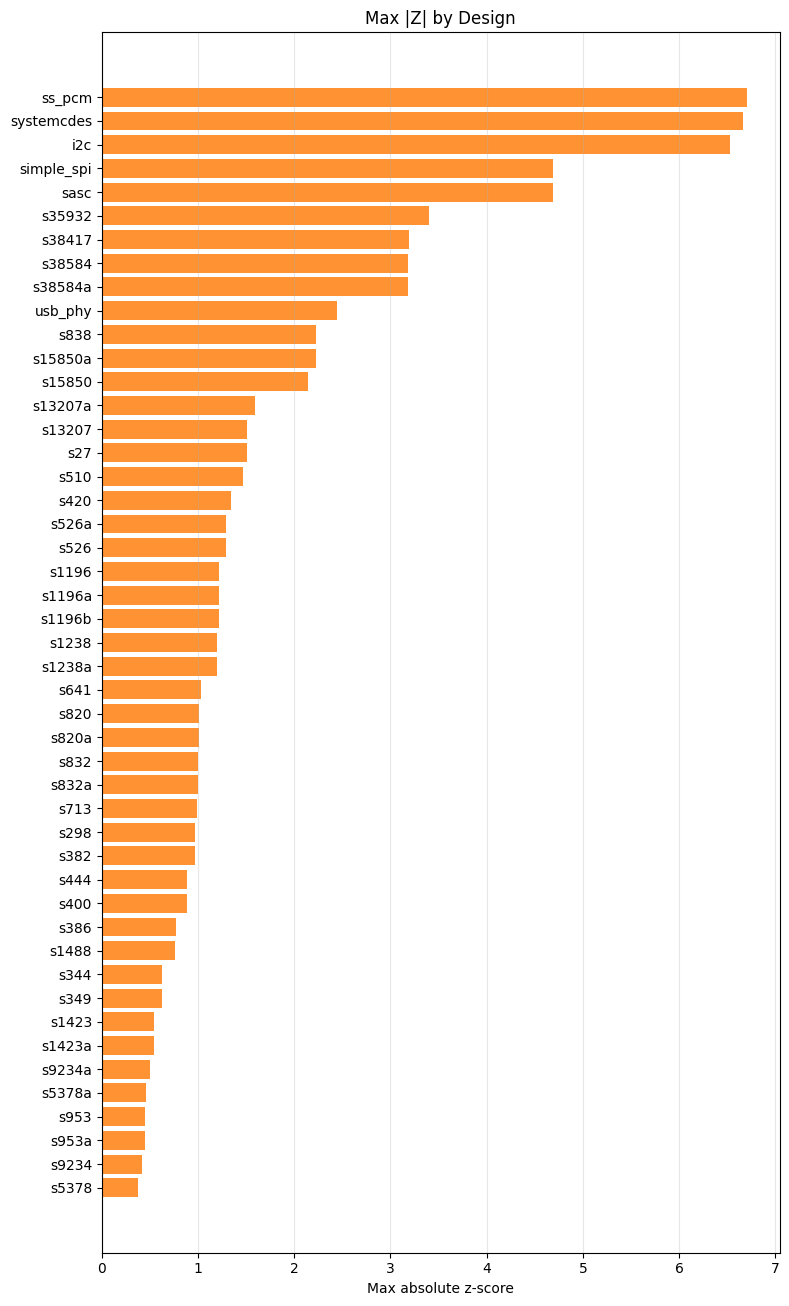

Saved design feature outlier bars to ..\results\mlp\run_085\design_feature_outlier_bars.png
Saved design outlier summary to ..\results\mlp\run_085\design_feature_outliers.csv
Saved design feature z-scores to ..\results\mlp\run_085\design_feature_zscores.csv
Top design feature outliers:


,design_name,max_abs_zscore,mean_abs_zscore
0,ss_pcm,6.7098,0.8377
1,systemcdes,6.6644,1.9413
2,i2c,6.5251,1.1278
3,simple_spi,4.6927,1.3369
4,sasc,4.6927,1.1686
5,s35932,3.4000,0.8533
6,s38417,3.1918,0.6323
7,s38584,3.1783,0.7450
8,s38584a,3.1783,0.7450
9,usb_phy,2.4431,0.6693


In [ ]:
design_feature_df = pd.DataFrame(rows).groupby("design_name")[AST_FEATURE_COLUMNS].first().reset_index()

feature_matrix = design_feature_df[AST_FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)
feature_mean = feature_matrix.mean(axis=0)
feature_std = feature_matrix.std(axis=0)
feature_std[feature_std == 0.0] = 1.0
feature_z = (feature_matrix - feature_mean) / feature_std

outlier_table = pd.DataFrame({
    "design_name": design_feature_df["design_name"],
    "max_abs_zscore": feature_z.abs().max(axis=1),
    "mean_abs_zscore": feature_z.abs().mean(axis=1),
})
outlier_table = outlier_table.sort_values(["max_abs_zscore", "mean_abs_zscore"], ascending=False).reset_index(drop=True)

ordered_designs = outlier_table["design_name"].tolist()
ordered_feature_z = feature_z.set_index(design_feature_df["design_name"]).loc[ordered_designs]

heat_values = np.clip(ordered_feature_z.to_numpy(dtype=np.float32), -4.0, 4.0)
fig, ax = plt.subplots(figsize=(14, max(8, len(ordered_designs) * 0.28)))
im = ax.imshow(heat_values, aspect="auto", cmap="coolwarm", vmin=-4.0, vmax=4.0)
ax.set_title("Design AST Feature Z-Scores")
ax.set_xlabel("AST Feature")
ax.set_ylabel("Design")
ax.set_xticks(np.arange(len(AST_FEATURE_COLUMNS)))
ax.set_xticklabels(AST_FEATURE_COLUMNS, rotation=45, ha="right")
ax.set_yticks(np.arange(len(ordered_designs)))
ax.set_yticklabels(ordered_designs)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Z-score")
plt.tight_layout()
heatmap_plot_path = RUN_DIR / "design_feature_zscore_heatmap.png"
fig.savefig(heatmap_plot_path, dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, max(8, len(ordered_designs) * 0.28)))
ax.barh(ordered_designs, outlier_table["max_abs_zscore"], color="tab:orange", alpha=0.85)
ax.invert_yaxis()
ax.set_title("Max |Z| by Design")
ax.set_xlabel("Max absolute z-score")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
outlier_bar_plot_path = RUN_DIR / "design_feature_outlier_bars.png"
fig.savefig(outlier_bar_plot_path, dpi=200, bbox_inches="tight")
plt.show()

feature_z_table = pd.concat([design_feature_df[["design_name"]], feature_z], axis=1)
outlier_csv_path = RUN_DIR / "design_feature_outliers.csv"
outlier_z_csv_path = RUN_DIR / "design_feature_zscores.csv"
outlier_table.to_csv(outlier_csv_path, index=False)
feature_z_table.to_csv(outlier_z_csv_path, index=False)

print("Top design feature outliers:")
display(outlier_table.head(15).round(4))



## 4. Partition into Train/Test Split

Randomly shuffle rows and perform index-based split


In [5]:
rows_df = pd.DataFrame(rows)
design_groups = rows_df["design_name"].astype(str).to_numpy()
unique_designs = sorted(rows_df["design_name"].astype(str).unique().tolist())

if len(unique_designs) < 2:
    raise ValueError("Need at least 2 designs for GroupKFold.")

n_splits = min(NUM_FOLDS, len(unique_designs))
if n_splits < 2:
    raise ValueError("Need at least 2 folds for GroupKFold.")

cv = GroupKFold(n_splits=n_splits)
fold_splits = list(cv.split(rows_df, groups=design_groups))

fold_rows = []
for fold_number, (train_idx, test_idx) in enumerate(fold_splits, start=1):
    train_designs = sorted(rows_df.iloc[train_idx]["design_name"].astype(str).unique().tolist())
    test_designs = sorted(rows_df.iloc[test_idx]["design_name"].astype(str).unique().tolist())
    fold_rows.append({
        "fold": fold_number,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_design_count": len(train_designs),
        "test_design_count": len(test_designs),
        "train_designs": ", ".join(train_designs),
        "test_designs": ", ".join(test_designs),
    })

fold_info_table = pd.DataFrame(fold_rows)

print("Split mode: GroupKFold by design_name")
print("Requested folds:", NUM_FOLDS)
print("Using folds:", n_splits)
print("Total rows:", len(rows_df))
print("Total designs:", len(unique_designs))
print("Fold layout:")
display(fold_info_table)


Split mode: GroupKFold by design_name
Requested folds: 5
Using folds: 5
Total rows: 13536
Total designs: 47
Fold layout:


,fold,train_rows,test_rows,train_design_count,test_design_count,train_designs,test_designs
0,1,10656,2880,37,10,"i2c, s1196a, s1196b, s1238, s1238a, s13207a, s...","s1196, s13207, s15850, s349, s38584a, s510, s6..."
1,2,10656,2880,37,10,"s1196, s1196a, s1196b, s1238, s13207, s13207a,...","i2c, s1238a, s1488, s344, s38584, s444, s5378a..."
2,3,10944,2592,38,9,"i2c, s1196, s1196a, s1196b, s1238a, s13207, s1...","s1238, s1423a, s298, s38417, s420, s5378, s820..."
3,4,10944,2592,38,9,"i2c, s1196, s1196a, s1238, s1238a, s13207, s13...","s1196b, s1423, s27, s382, s400, s526a, s820, s..."
4,5,10944,2592,38,9,"i2c, s1196, s1196b, s1238, s1238a, s13207, s14...","s1196a, s13207a, s15850a, s35932, s386, s526, ..."


## 5. Build Feature And Target Matrices


In [6]:
def build_xy(train_rows, test_rows):
    train_df = pd.DataFrame(train_rows)
    test_df = pd.DataFrame(test_rows)

    feature_cols = AST_FEATURE_COLUMNS + NUMERIC_CONFIG_COLUMNS

    x_train_num = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)
    x_test_num = test_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)

    train_cat_parts = []
    test_cat_parts = []
    cat_feature_names = []

    for col in CATEGORICAL_CONFIG_COLUMNS:
        train_one_hot = pd.get_dummies(train_df[col].astype(str), prefix=col)
        test_one_hot = pd.get_dummies(test_df[col].astype(str), prefix=col)
        test_one_hot = test_one_hot.reindex(columns=train_one_hot.columns, fill_value=0)

        train_cat_parts.append(train_one_hot)
        test_cat_parts.append(test_one_hot)
        cat_feature_names.extend(train_one_hot.columns.tolist())

    if train_cat_parts:
        x_train_cat = pd.concat(train_cat_parts, axis=1)
        x_test_cat = pd.concat(test_cat_parts, axis=1)
        x_train_df = pd.concat([x_train_num, x_train_cat], axis=1)
        x_test_df = pd.concat([x_test_num, x_test_cat], axis=1)
    else:
        x_train_df = x_train_num.copy()
        x_test_df = x_test_num.copy()

    y_train = train_df[TARGET_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()
    y_test = test_df[TARGET_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()

    all_feature_names = feature_cols + cat_feature_names
    return (
        x_train_df.to_numpy(dtype=np.float32),
        x_test_df.to_numpy(dtype=np.float32),
        y_train,
        y_test,
        all_feature_names,
    )

print(pd.DataFrame(rows).columns.tolist())

['design_name', 'design_id', 'recipe_id', 'flow_mode', 'total_input_bits', 'total_output_bits', 'total_register_bits', 'total_logic_operator_bits', 'total_adder_sub_bits', 'total_multiplier_bits', 'total_comparator_bits', 'total_multiplexer_bits', 'total_shift_bits', 'total_division_bits', 'total_memory_write_addr_bits', 'total_memory_write_addr_width', 'total_memory_read_addr_bits', 'total_memory_read_addr_width', 'average_tree_depth', 'average_wire_width', 'worst_slack_ns', 'total_negative_slack_ns', 'run_utc', 'run_id', 'top_module', 'clock_port', 'abc_fast_cfg', 'clock_period_ns_cfg', 'max_fanout_cfg', 'max_transition_ns_cfg', 'max_capacitance_ff_cfg', 'fanout_load_cfg', 'num_rtl_files', 'ast_json_path', 'ast_log_path', 'netlist_path', 'sdc_path', 'run_dir', 'area_um2', 'clock_period_ns_sta', 'utilization_pct', 'tool_runtime_s', 'status', 'error_stage', 'error_message']


## 6. Train MLP

Train a small fully connected feed-forward network with ReLU activations and dropout.


In [7]:
import copy


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_1, hidden_2, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, 1)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x


def calc_r2_1d(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 0.0
    return 1.0 - (ss_res / ss_tot)


def get_metrics(y_true, y_pred):
    diff = y_pred - y_true
    mae = np.mean(np.abs(diff), axis=0)
    rmse = np.sqrt(np.mean(diff ** 2, axis=0))
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_true - y_true.mean(axis=0)) ** 2, axis=0)
    r2 = 1.0 - np.divide(ss_res, ss_tot, out=np.zeros_like(ss_res), where=ss_tot != 0)
    return {"mae": mae, "rmse": rmse, "r2": r2}


def make_loss():
    if LOSS_NAME == "mse":
        return nn.MSELoss()
    return nn.SmoothL1Loss(beta=SMOOTH_L1_BETA)


loss_history_by_target = {name: [] for name in TARGET_COLUMNS}
train_r2_history_by_target = {name: [] for name in TARGET_COLUMNS}
test_r2_history_by_target = {name: [] for name in TARGET_COLUMNS}
fold_metric_rows = []
prediction_rows = []
fold_feature_rows = []
training_summary_rows = []
best_run_by_target = {}

oof_truth = rows_df[TARGET_COLUMNS].astype(np.float32).to_numpy()
oof_pred = np.full_like(oof_truth, np.nan, dtype=np.float32)

for fold_number, (train_idx, test_idx) in enumerate(fold_splits, start=1):
    print()
    print(f"Starting fold {fold_number}/{n_splits}")

    train_rows = rows_df.iloc[train_idx].to_dict("records")
    test_rows = rows_df.iloc[test_idx].to_dict("records")

    x_train, x_test, y_train, y_test, feature_columns = build_xy(train_rows, test_rows)
    fold_feature_rows.append({"fold": fold_number, "encoded_feature_count": len(feature_columns)})

    train_mean = x_train.mean(axis=0)
    train_std = x_train.std(axis=0)
    train_std[train_std == 0.0] = 1.0

    x_train = (x_train - train_mean) / train_std
    x_test = (x_test - train_mean) / train_std

    x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=DEVICE)
    x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=DEVICE)

    fold_train_pred = np.zeros_like(y_train)
    fold_test_pred = np.zeros_like(y_test)

    for target_idx, target_name in enumerate(TARGET_COLUMNS):
        print(f"  Training target: {target_name}")

        y_train_target = y_train[:, target_idx].astype(np.float32)
        y_test_target = y_test[:, target_idx].astype(np.float32)

        target_mean = float(y_train_target.mean())
        target_std = float(y_train_target.std())
        if target_std == 0.0:
            target_std = 1.0

        y_train_scaled = ((y_train_target - target_mean) / target_std).astype(np.float32)
        y_train_tensor = torch.tensor(y_train_scaled.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

        model = MLP(len(feature_columns), HIDDEN_DIM_1, HIDDEN_DIM_2, dropout=DROPOUT).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        loss_fn = make_loss()

        loss_list = []
        train_r2_list = []
        test_r2_list = []

        best_epoch = 0
        best_test_r2 = -np.inf
        best_state = copy.deepcopy(model.state_dict())
        best_train_pred = None
        best_test_pred = None

        for epoch in range(1, EPOCHS + 1):
            model.train()
            optimizer.zero_grad()
            pred_train_scaled = model(x_train_tensor)
            loss = loss_fn(pred_train_scaled, y_train_tensor)
            loss.backward()
            optimizer.step()

            loss_list.append(float(loss.item()))

            model.eval()
            with torch.no_grad():
                train_scaled_now = model(x_train_tensor).cpu().numpy().reshape(-1)
                test_scaled_now = model(x_test_tensor).cpu().numpy().reshape(-1)

            train_pred_now = (train_scaled_now * target_std) + target_mean
            test_pred_now = (test_scaled_now * target_std) + target_mean

            train_r2_now = calc_r2_1d(y_train_target, train_pred_now)
            test_r2_now = calc_r2_1d(y_test_target, test_pred_now)
            train_r2_list.append(train_r2_now)
            test_r2_list.append(test_r2_now)

            if test_r2_now > best_test_r2:
                best_test_r2 = test_r2_now
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                best_train_pred = train_pred_now.copy()
                best_test_pred = test_pred_now.copy()

            if epoch == 1 or epoch % 25 == 0 or epoch == EPOCHS:
                print(f"    Epoch {epoch:03d} | train_loss={loss.item():.6f} | test_r2={test_r2_now:.4f}")

        model.load_state_dict(best_state)
        if target_name not in best_run_by_target or best_test_r2 > best_run_by_target[target_name]["best_test_r2"]:
            best_run_by_target[target_name] = {
                "fold": int(fold_number),
                "best_test_r2": float(best_test_r2),
                "input_dim": int(len(feature_columns)),
                "state_dict": {k: v.detach().cpu().clone() for k, v in best_state.items()},
                "sample_input": x_test[:1].copy(),
                "sample_design_name": str(test_rows[0]["design_name"]),
                "sample_true_value": float(y_test[0, target_idx]),
                "target_mean": float(target_mean),
                "target_std": float(target_std),
            }
        fold_train_pred[:, target_idx] = best_train_pred
        fold_test_pred[:, target_idx] = best_test_pred

        loss_history_by_target[target_name].append(loss_list)
        train_r2_history_by_target[target_name].append(train_r2_list)
        test_r2_history_by_target[target_name].append(test_r2_list)
        training_summary_rows.append({
            "fold": fold_number,
            "target": target_name,
            "best_epoch": int(best_epoch),
            "best_test_r2": float(best_test_r2),
            "completed_epoch": int(EPOCHS),
        })

    oof_pred[test_idx] = fold_test_pred

    for row_index, row, pred, truth in zip(test_idx, test_rows, fold_test_pred, y_test):
        prediction_rows.append({
            "row_index": int(row_index),
            "fold": fold_number,
            "design_name": row["design_name"],
            "recipe_id": row["recipe_id"],
            "pred_worst_slack_ns": float(pred[0]),
            "true_worst_slack_ns": float(truth[0]),
            "wns_error": float(pred[0] - truth[0]),
            "pred_total_negative_slack_ns": float(pred[1]),
            "true_total_negative_slack_ns": float(truth[1]),
            "tns_error": float(pred[1] - truth[1]),
        })

    split_pairs = [("train", y_train, fold_train_pred), ("test", y_test, fold_test_pred)]
    for split_name, y_true_split, y_pred_split in split_pairs:
        scores = get_metrics(y_true_split, y_pred_split)
        for target_idx, target_name in enumerate(TARGET_COLUMNS):
            fold_metric_rows.append({
                "fold": fold_number,
                "split": split_name,
                "target": target_name,
                "mae": float(scores["mae"][target_idx]),
                "rmse": float(scores["rmse"][target_idx]),
                "r2": float(scores["r2"][target_idx]),
            })

training_summary_table = pd.DataFrame(training_summary_rows)

print()
print("Finished all folds.")
print("OOF predictions shape:", oof_pred.shape)
print("Encoded feature counts by fold:")
display(pd.DataFrame(fold_feature_rows))




Starting fold 1/5
  Training target: worst_slack_ns
    Epoch 001 | train_loss=1.028660 | test_r2=-0.0635
    Epoch 025 | train_loss=0.731536 | test_r2=0.3325
    Epoch 050 | train_loss=0.306967 | test_r2=0.7739
    Epoch 075 | train_loss=0.182407 | test_r2=0.9044
    Epoch 100 | train_loss=0.160650 | test_r2=0.9172
    Epoch 125 | train_loss=0.149374 | test_r2=0.9259
    Epoch 150 | train_loss=0.140669 | test_r2=0.9301
    Epoch 175 | train_loss=0.133782 | test_r2=0.9316
    Epoch 200 | train_loss=0.124389 | test_r2=0.9317
    Epoch 225 | train_loss=0.119927 | test_r2=0.9302
    Epoch 250 | train_loss=0.112920 | test_r2=0.9289
    Epoch 275 | train_loss=0.104565 | test_r2=0.9280
    Epoch 300 | train_loss=0.096808 | test_r2=0.9287
    Epoch 325 | train_loss=0.089612 | test_r2=0.9291
    Epoch 350 | train_loss=0.082297 | test_r2=0.9308
    Epoch 375 | train_loss=0.076557 | test_r2=0.9323
    Epoch 400 | train_loss=0.069364 | test_r2=0.9361
  Training target: total_negative_slack_ns
  

,fold,encoded_feature_count
0,1,23
1,2,23
2,3,23
3,4,23
4,5,23


## 6.1 Training Loss Curve


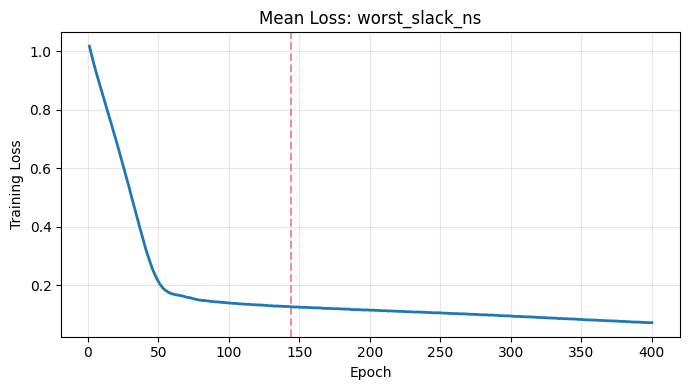

Saved training loss plot to ..\results\mlp\run_085\training_loss_worst_slack_ns.png


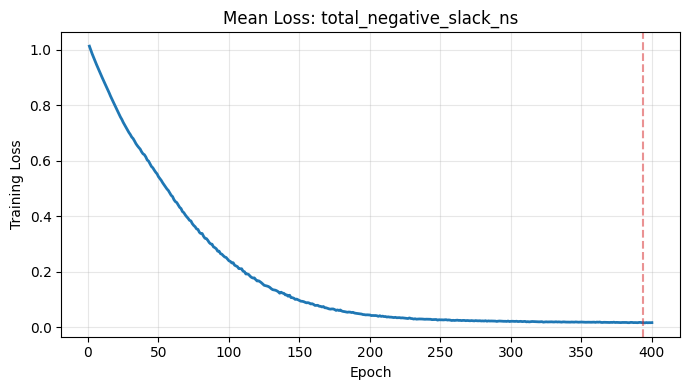

Saved training loss plot to ..\results\mlp\run_085\training_loss_total_negative_slack_ns.png


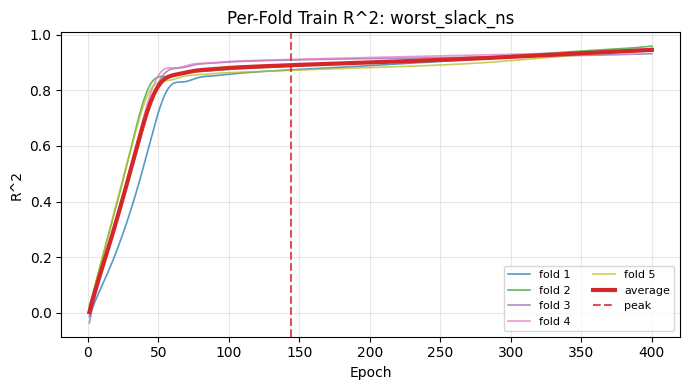

Saved per-fold train R^2 plot to ..\results\mlp\run_085\per_fold_train_r2_worst_slack_ns.png


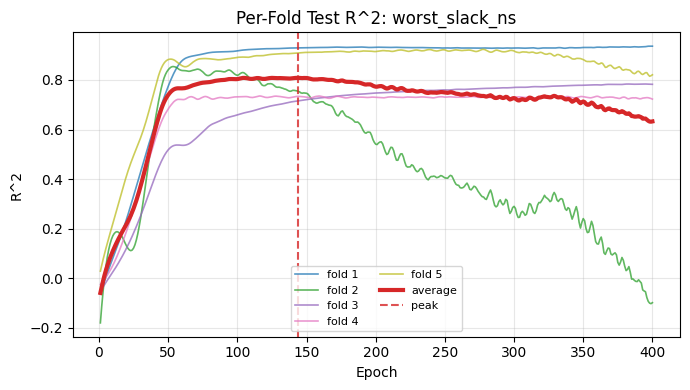

Saved per-fold test R^2 plot to ..\results\mlp\run_085\per_fold_test_r2_worst_slack_ns.png


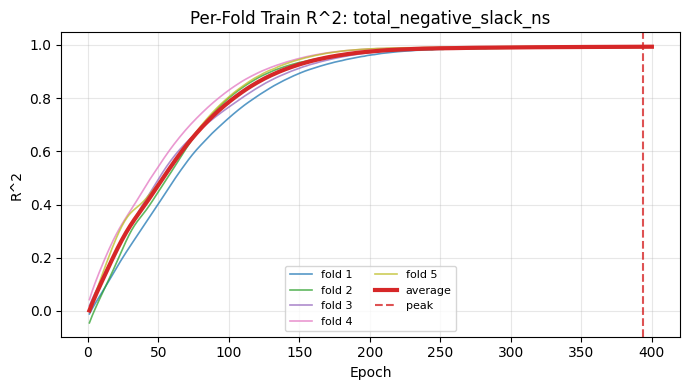

Saved per-fold train R^2 plot to ..\results\mlp\run_085\per_fold_train_r2_total_negative_slack_ns.png


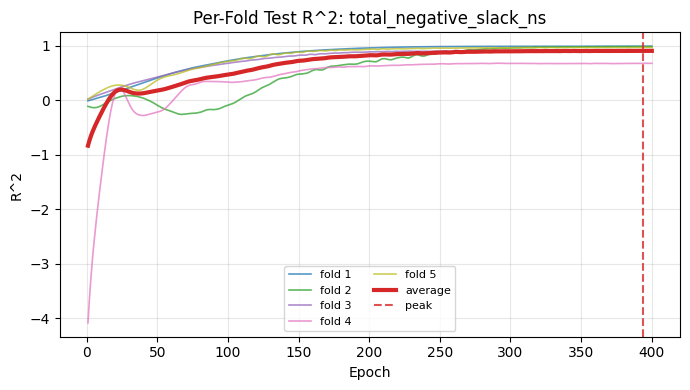

Saved per-fold test R^2 plot to ..\results\mlp\run_085\per_fold_test_r2_total_negative_slack_ns.png
Peak summary below per-fold R^2 plot:


,target,peak_of_average_curve_r2,peak_of_average_curve_epoch,mean_fold_peak_r2,std_fold_peak_r2,mean_fold_peak_epoch
0,worst_slack_ns,0.8083,144,0.8464,0.0870,248.4
1,total_negative_slack_ns,0.9098,394,0.9104,0.1316,369.8


In [ ]:
max_recorded_epochs = 0
for target_name in TARGET_COLUMNS:
    for history in loss_history_by_target[target_name]:
        if len(history) > max_recorded_epochs:
            max_recorded_epochs = len(history)


def average_histories(history_list, total_epochs):
    filled = []
    for history in history_list:
        row = list(history)
        if len(row) == 0:
            row = [np.nan] * total_epochs
        elif len(row) < total_epochs:
            row = row + [row[-1]] * (total_epochs - len(row))
        filled.append(row)
    return np.nanmean(np.array(filled, dtype=np.float32), axis=0)


r2_history_df = pd.DataFrame({"epoch": np.arange(1, max_recorded_epochs + 1)})
for target_name in TARGET_COLUMNS:
    r2_history_df[f"mean_loss_{target_name}"] = average_histories(loss_history_by_target[target_name], max_recorded_epochs)
    r2_history_df[f"mean_train_r2_{target_name}"] = average_histories(train_r2_history_by_target[target_name], max_recorded_epochs)
    r2_history_df[f"mean_test_r2_{target_name}"] = average_histories(test_r2_history_by_target[target_name], max_recorded_epochs)

peak_epoch_by_target = {}
peak_test_r2_by_target = {}
for target_name in TARGET_COLUMNS:
    peak_idx = int(r2_history_df[f"mean_test_r2_{target_name}"].idxmax())
    peak_epoch_by_target[target_name] = int(r2_history_df.loc[peak_idx, "epoch"])
    peak_test_r2_by_target[target_name] = float(r2_history_df.loc[peak_idx, f"mean_test_r2_{target_name}"])

for target_name in TARGET_COLUMNS:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(r2_history_df["epoch"], r2_history_df[f"mean_loss_{target_name}"], linewidth=2)
    ax.axvline(peak_epoch_by_target[target_name], linestyle="--", alpha=0.5, color="tab:red")
    ax.set_title(f"Mean Loss: {target_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    loss_plot_path = RUN_DIR / f"training_loss_{target_name}.png"
    fig.savefig(loss_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

per_fold_r2_df = pd.DataFrame({"epoch": np.arange(1, max_recorded_epochs + 1)})
for target_name in TARGET_COLUMNS:
    for fold_index, train_history in enumerate(train_r2_history_by_target[target_name], start=1):
        per_fold_r2_df[f"train_r2_fold_{fold_index}_{target_name}"] = train_history
    for fold_index, test_history in enumerate(test_r2_history_by_target[target_name], start=1):
        per_fold_r2_df[f"test_r2_fold_{fold_index}_{target_name}"] = test_history

for target_name in TARGET_COLUMNS:
    fold_colors = plt.cm.tab10(np.linspace(0.0, 0.85, len(train_r2_history_by_target[target_name])))

    fig, ax = plt.subplots(figsize=(7, 4))
    for fold_index, train_history in enumerate(train_r2_history_by_target[target_name], start=1):
        ax.plot(range(1, len(train_history) + 1), train_history, linewidth=1.2, alpha=0.75, color=fold_colors[fold_index - 1], label=f"fold {fold_index}")
    ax.plot(r2_history_df["epoch"], r2_history_df[f"mean_train_r2_{target_name}"], linewidth=3, color="tab:red", label="average")
    ax.axvline(peak_epoch_by_target[target_name], linestyle="--", alpha=0.8, color="tab:red", label="peak")
    ax.set_title(f"Per-Fold Train R^2: {target_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("R^2")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    train_plot_path = RUN_DIR / f"per_fold_train_r2_{target_name}.png"
    fig.savefig(train_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    for fold_index, test_history in enumerate(test_r2_history_by_target[target_name], start=1):
        ax.plot(range(1, len(test_history) + 1), test_history, linewidth=1.2, alpha=0.75, color=fold_colors[fold_index - 1], label=f"fold {fold_index}")
    ax.plot(r2_history_df["epoch"], r2_history_df[f"mean_test_r2_{target_name}"], linewidth=3, color="tab:red", label="average")
    ax.axvline(peak_epoch_by_target[target_name], linestyle="--", alpha=0.8, color="tab:red", label="peak")
    ax.set_title(f"Per-Fold Test R^2: {target_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("R^2")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    test_plot_path = RUN_DIR / f"per_fold_test_r2_{target_name}.png"
    fig.savefig(test_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

fold_peak_summary_rows = []
for target_name in TARGET_COLUMNS:
    target_summary = training_summary_table[training_summary_table["target"] == target_name]
    fold_peak_summary_rows.append({
        "target": target_name,
        "peak_of_average_curve_r2": peak_test_r2_by_target[target_name],
        "peak_of_average_curve_epoch": peak_epoch_by_target[target_name],
        "mean_fold_peak_r2": float(target_summary["best_test_r2"].mean()),
        "std_fold_peak_r2": float(target_summary["best_test_r2"].std(ddof=1)) if len(target_summary) > 1 else 0.0,
        "mean_fold_peak_epoch": float(target_summary["best_epoch"].mean()),
    })

fold_peak_summary_table = pd.DataFrame(fold_peak_summary_rows).round(4)
print("Peak summary below per-fold R^2 plot:")
display(fold_peak_summary_table)



## 7. Evaluate Predictions


In [9]:
fold_metrics_table = pd.DataFrame(fold_metric_rows)
test_fold_metrics = fold_metrics_table[fold_metrics_table["split"] == "test"].copy()

summary_rows = []
for target_name in TARGET_COLUMNS:
    target_metrics = test_fold_metrics[test_fold_metrics["target"] == target_name]
    summary_rows.append({
        "target": target_name,
        "mean_r2": float(target_metrics["r2"].mean()),
        "var_r2": float(target_metrics["r2"].var(ddof=1)),
        "mean_mae": float(target_metrics["mae"].mean()),
        "var_mae": float(target_metrics["mae"].var(ddof=1)),
    })

metrics_table = pd.DataFrame(summary_rows).round(4)

oof_metric_values = get_metrics(oof_truth, oof_pred)
oof_metric_rows = []
for target_idx, target_name in enumerate(TARGET_COLUMNS):
    oof_metric_rows.append({
        "target": target_name,
        "oof_r2": float(oof_metric_values["r2"][target_idx]),
        "oof_mae": float(oof_metric_values["mae"][target_idx]),
        "oof_rmse": float(oof_metric_values["rmse"][target_idx]),
    })

oof_metrics_table = pd.DataFrame(oof_metric_rows).round(4)

prediction_table = pd.DataFrame(prediction_rows).sort_values(["row_index"]).reset_index(drop=True)

design_metric_rows = []
target_column_map = [
    ("worst_slack_ns", "pred_worst_slack_ns", "true_worst_slack_ns", "wns_error"),
    ("total_negative_slack_ns", "pred_total_negative_slack_ns", "true_total_negative_slack_ns", "tns_error"),
]

for design_name, design_df in prediction_table.groupby("design_name"):
    design_fold = int(design_df["fold"].iloc[0])
    for target_name, pred_col, true_col, error_col in target_column_map:
        y_true = design_df[true_col].to_numpy(dtype=np.float32)
        y_pred = design_df[pred_col].to_numpy(dtype=np.float32)
        errors = design_df[error_col].to_numpy(dtype=np.float32)
        design_metric_rows.append({
            "design_name": design_name,
            "fold": design_fold,
            "target": target_name,
            "design_rows": int(len(design_df)),
            "r2": float(calc_r2_1d(y_true, y_pred)),
            "mae": float(np.mean(np.abs(errors))),
            "rmse": float(np.sqrt(np.mean(errors ** 2))),
            "true_min": float(y_true.min()),
            "true_max": float(y_true.max()),
            "true_mean": float(y_true.mean()),
            "pred_mean": float(y_pred.mean()),
            "mean_error": float(errors.mean()),
        })

design_metrics_table = pd.DataFrame(design_metric_rows).sort_values(["target", "r2", "design_name"]).reset_index(drop=True)

design_summary_rows = []
for target_name in TARGET_COLUMNS:
    target_design_metrics = design_metrics_table[design_metrics_table["target"] == target_name].reset_index(drop=True)
    worst_row = target_design_metrics.loc[target_design_metrics["r2"].idxmin()]
    best_row = target_design_metrics.loc[target_design_metrics["r2"].idxmax()]
    design_summary_rows.append({
        "target": target_name,
        "design_count": int(target_design_metrics["design_name"].nunique()),
        "mean_r2": float(target_design_metrics["r2"].mean()),
        "std_r2": float(target_design_metrics["r2"].std(ddof=1)) if len(target_design_metrics) > 1 else 0.0,
        "min_r2": float(target_design_metrics["r2"].min()),
        "median_r2": float(target_design_metrics["r2"].median()),
        "max_r2": float(target_design_metrics["r2"].max()),
        "mean_mae": float(target_design_metrics["mae"].mean()),
        "median_mae": float(target_design_metrics["mae"].median()),
        "max_mae": float(target_design_metrics["mae"].max()),
        "worst_design_r2": worst_row["design_name"],
        "best_design_r2": best_row["design_name"],
    })

design_metrics_summary_table = pd.DataFrame(design_summary_rows).round(4)
metrics_table


,target,mean_r2,var_r2,mean_mae,var_mae
0,worst_slack_ns,0.8464,0.0076,0.1162,0.0009
1,total_negative_slack_ns,0.9104,0.0173,4.6484,5.8182


## 8. Prediction Comparison Table


In [ ]:
fold_feature_table = pd.DataFrame(fold_feature_rows)

fold_metrics_path = RUN_DIR / "fold_metrics.csv"
summary_metrics_path = RUN_DIR / "cv_summary_metrics.csv"
oof_metrics_path = RUN_DIR / "oof_metrics.csv"
predictions_path = RUN_DIR / "oof_predictions.csv"
design_metrics_path = RUN_DIR / "design_metrics.csv"
design_metrics_summary_path = RUN_DIR / "design_metrics_summary.csv"
summary_path = RUN_DIR / "run_summary.json"
r2_history_path = RUN_DIR / "r2_history.csv"
fold_info_path = RUN_DIR / "fold_info.csv"
fold_feature_path = RUN_DIR / "fold_feature_counts.csv"
training_summary_path = RUN_DIR / "fold_training_summary.csv"


def table_records(df):
    out = []
    for row in df.to_dict(orient="records"):
        clean_row = {}
        for key, value in row.items():
            if isinstance(value, np.generic):
                clean_row[key] = value.item()
            else:
                clean_row[key] = value
        out.append(clean_row)
    return out


fold_metrics_table.to_csv(fold_metrics_path, index=False)
metrics_table.to_csv(summary_metrics_path, index=False)
oof_metrics_table.to_csv(oof_metrics_path, index=False)
prediction_table.to_csv(predictions_path, index=False)
design_metrics_table.to_csv(design_metrics_path, index=False)
design_metrics_summary_table.to_csv(design_metrics_summary_path, index=False)
r2_history_df.to_csv(r2_history_path, index=False)
fold_info_table.to_csv(fold_info_path, index=False)
fold_feature_table.to_csv(fold_feature_path, index=False)
training_summary_table.to_csv(training_summary_path, index=False)

summary = {
    "model": "mlp",
    "data_path": str(DATA_PATH),
    "run_dir": str(RUN_DIR),
    "total_rows": int(len(rows)),
    "total_designs": int(len(unique_designs)),
    "split_mode": "group_k_fold_design",
    "requested_num_folds": int(NUM_FOLDS),
    "num_folds": int(n_splits),
    "use_fixed_seed": bool(USE_FIXED_SEED),
    "random_seed": int(RANDOM_SEED) if USE_FIXED_SEED else None,
    "ast_feature_columns": AST_FEATURE_COLUMNS,
    "numeric_config_columns": NUMERIC_CONFIG_COLUMNS,
    "categorical_config_columns": CATEGORICAL_CONFIG_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "trained_separate_models": True,
    "loss_name": str(LOSS_NAME),
    "smooth_l1_beta": float(SMOOTH_L1_BETA),
    "encoded_feature_count_by_fold": table_records(fold_feature_table),
    "folds": table_records(fold_info_table),
    "cv_summary_metrics": table_records(metrics_table),
    "oof_metrics": table_records(oof_metrics_table),
    "design_metrics_summary": table_records(design_metrics_summary_table),
    "fold_training_summary": table_records(training_summary_table),
    "peak_epoch_by_target": peak_epoch_by_target,
    "peak_test_r2_by_target": peak_test_r2_by_target,
    "hyperparameters": {
        "num_folds": int(NUM_FOLDS),
        "use_fixed_seed": bool(USE_FIXED_SEED),
        "random_seed": int(RANDOM_SEED) if USE_FIXED_SEED else None,
        "learning_rate": float(LEARNING_RATE),
        "loss_name": str(LOSS_NAME),
        "smooth_l1_beta": float(SMOOTH_L1_BETA),
        "weight_decay": float(WEIGHT_DECAY),
        "epochs": int(EPOCHS),
        "hidden_dim_1": int(HIDDEN_DIM_1),
        "hidden_dim_2": int(HIDDEN_DIM_2),
        "dropout": float(DROPOUT),
    },
}

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

prediction_table.head()



Saved fold metrics to ..\results\mlp\run_085\fold_metrics.csv
Saved cross-validation summary to ..\results\mlp\run_085\cv_summary_metrics.csv
Saved OOF metrics to ..\results\mlp\run_085\oof_metrics.csv
Saved OOF predictions to ..\results\mlp\run_085\oof_predictions.csv
Saved per-design metrics to ..\results\mlp\run_085\design_metrics.csv
Saved per-design metric summary to ..\results\mlp\run_085\design_metrics_summary.csv
Saved run summary to ..\results\mlp\run_085\run_summary.json
Saved R^2 history to ..\results\mlp\run_085\r2_history.csv
Saved fold training summary to ..\results\mlp\run_085\fold_training_summary.csv


,row_index,fold,design_name,recipe_id,pred_worst_slack_ns,true_worst_slack_ns,wns_error,pred_total_negative_slack_ns,true_total_negative_slack_ns,tns_error
0,0,2,i2c,abcfast_clk0p1_fo16_tr0p16_cap100_fload1,-0.062813,-0.380054,0.317241,-9.050723,-31.437370,22.386646
1,1,2,i2c,abcfast_clk0p1_fo16_tr0p16_cap40_fload1,-0.137886,-0.381261,0.243375,-9.721907,-33.426956,23.705050
2,2,2,i2c,abcfast_clk0p1_fo16_tr0p16_cap60_fload1,-0.114987,-0.380054,0.265067,-9.498175,-31.437370,21.939196
3,3,2,i2c,abcfast_clk0p1_fo16_tr0p16_cap80_fload1,-0.093824,-0.380054,0.286230,-9.274444,-31.437370,22.162926
4,4,2,i2c,abcfast_clk0p1_fo16_tr0p24_cap100_fload1,-0.022263,-0.380054,0.357791,-9.935280,-31.437370,21.502090


## 9. Predicted vs Actual Scatter Plots


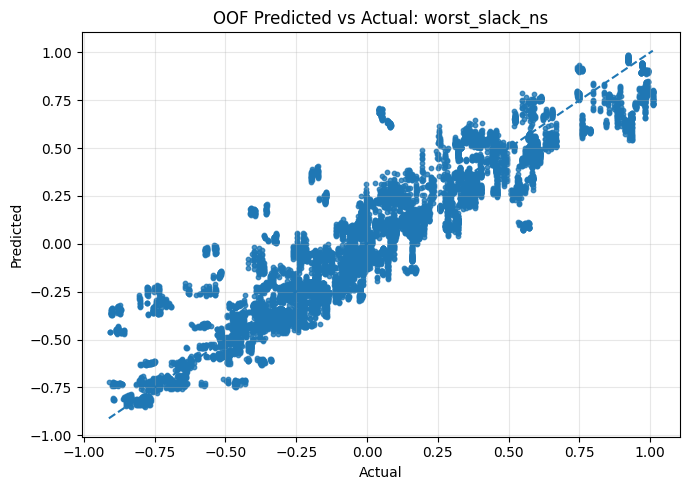

Saved predicted vs actual scatter plot to ..\results\mlp\run_085\predicted_vs_actual_scatter_worst_slack_ns.png


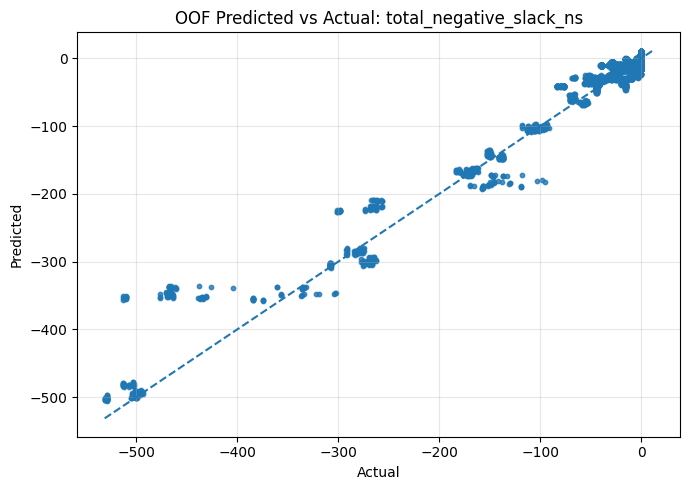

Saved predicted vs actual scatter plot to ..\results\mlp\run_085\predicted_vs_actual_scatter_total_negative_slack_ns.png


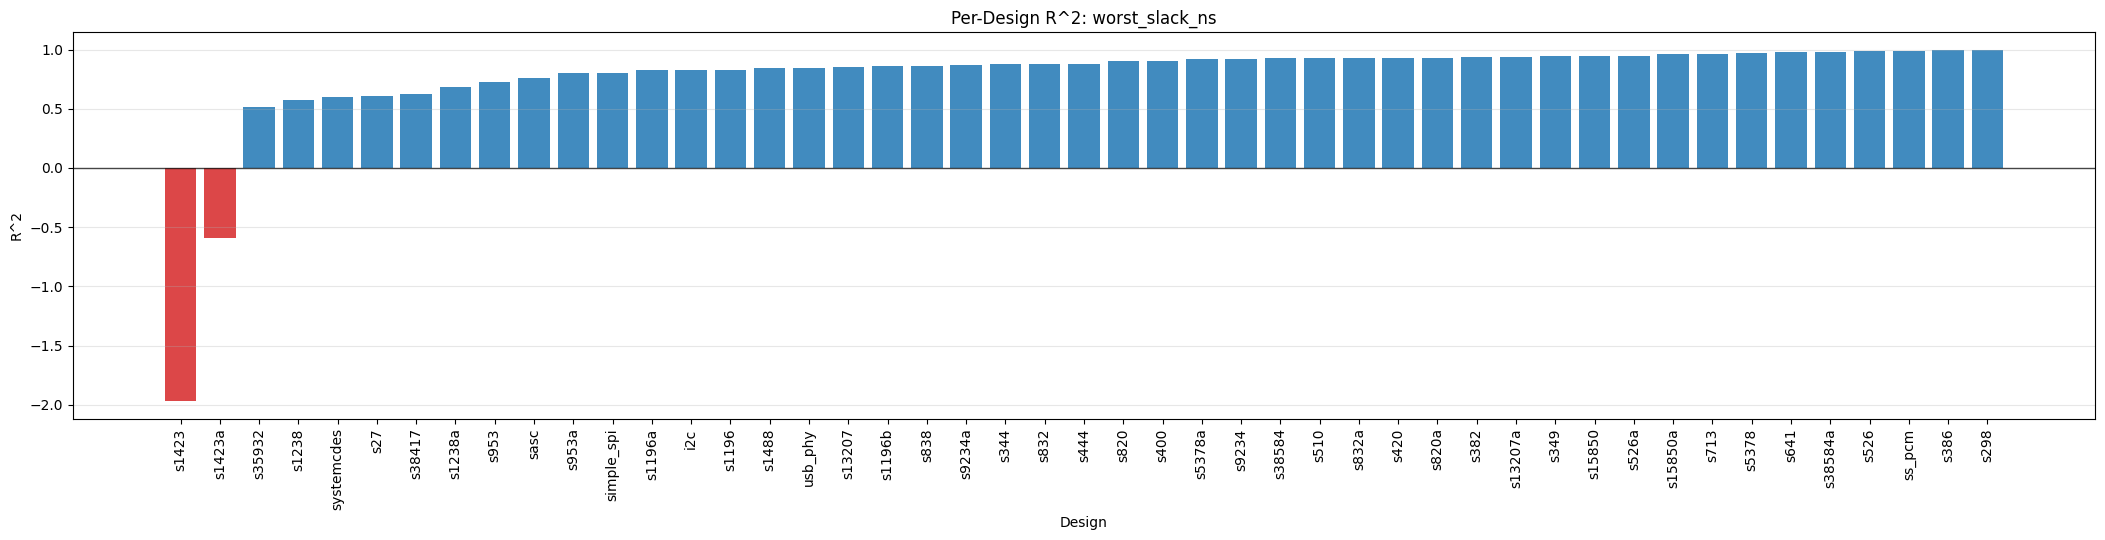

Saved per-design R^2 bar chart to ..\results\mlp\run_085\per_design_r2_bar_chart_worst_slack_ns.png


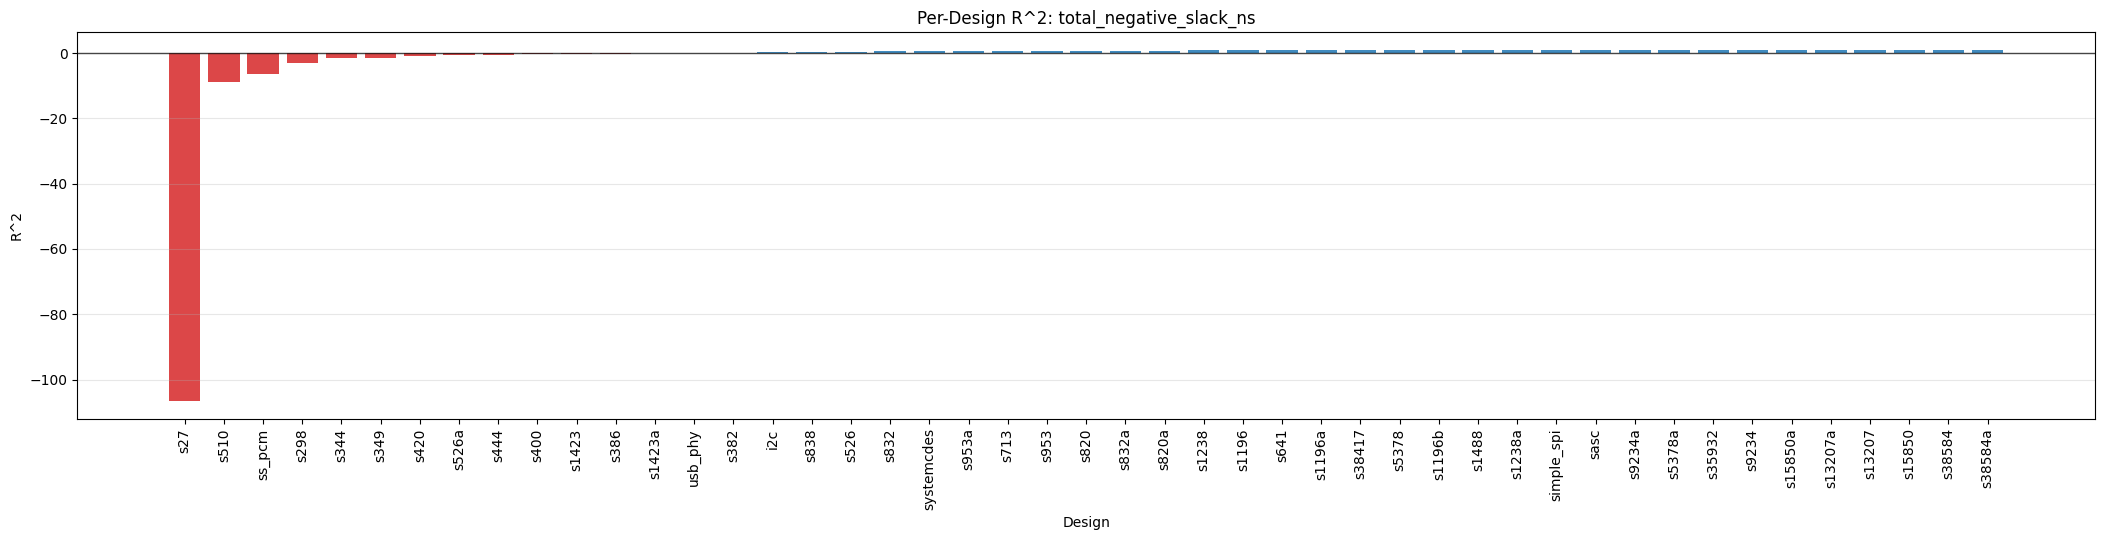

Saved per-design R^2 bar chart to ..\results\mlp\run_085\per_design_r2_bar_chart_total_negative_slack_ns.png
Run summary:


,item,value
0,model,mlp
1,split_mode,group_k_fold_design
2,requested_num_folds,5
3,num_folds,5
4,total_rows,13536
5,total_designs,47
6,use_fixed_seed,True
7,random_seed,11
8,loss_name,mse
9,smooth_l1_beta,1.0


Fold summary:


,fold,train_rows,test_rows,train_design_count,test_design_count,train_designs,test_designs
0,1,10656,2880,37,10,"i2c, s1196a, s1196b, s1238, s1238a, s13207a, s...","s1196, s13207, s15850, s349, s38584a, s510, s6..."
1,2,10656,2880,37,10,"s1196, s1196a, s1196b, s1238, s13207, s13207a,...","i2c, s1238a, s1488, s344, s38584, s444, s5378a..."
2,3,10944,2592,38,9,"i2c, s1196, s1196a, s1196b, s1238a, s13207, s1...","s1238, s1423a, s298, s38417, s420, s5378, s820..."
3,4,10944,2592,38,9,"i2c, s1196, s1196a, s1238, s1238a, s13207, s13...","s1196b, s1423, s27, s382, s400, s526a, s820, s..."
4,5,10944,2592,38,9,"i2c, s1196, s1196b, s1238, s1238a, s13207, s14...","s1196a, s13207a, s15850a, s35932, s386, s526, ..."


Cross-validation summary:


...

,design_name,fold,target,design_rows,r2,mae,rmse,true_min,true_max,true_mean,pred_mean,mean_error
0,s27,4,total_negative_slack_ns,288,-106.593407,1.345276,1.781670,-0.465295,0.000000,-0.081775,-0.865279,-0.783504
1,s510,1,total_negative_slack_ns,288,-8.892974,2.527431,4.009983,-3.521289,0.000000,-0.830438,-2.964176,-2.133738
2,ss_pcm,3,total_negative_slack_ns,288,-6.275077,14.390986,15.772853,-16.613008,0.000000,-3.321836,-17.712822,-14.390986
3,s298,3,total_negative_slack_ns,288,-2.988605,1.701338,2.265973,-3.157489,0.000000,-0.592838,-2.162953,-1.570116
4,s344,2,total_negative_slack_ns,288,-1.512774,1.989061,2.558297,-4.482791,0.000000,-0.950855,-2.897216,-1.946361
...,...,...,...,...,...,...,...,...,...,...,...,...
89,s38584a,1,worst_slack_ns,288,0.980936,0.033374,0.042367,-0.817609,0.210628,-0.351612,-0.341750,0.009863
90,s526,5,worst_slack_ns,288,0.989101,0.033868,0.041933,-0.214164,0.991581,0.302708,0.269878,-0.032830
91,ss_pcm,3,worst_slack_ns,288,0.991060,0.024741,0.030367,-0.232788,0.749678,0.221903,0.216912,-0.004991
92,s386,5,worst_slack_ns,288,0.995123,0.016819,0.022140,-0.305959,0.652468,0.115376,0.122714,0.007338


Training summary:


,fold,target,best_epoch,best_test_r2,completed_epoch
0,1,worst_slack_ns,400,0.936067,400
1,1,total_negative_slack_ns,395,0.995056,400
2,2,worst_slack_ns,54,0.853752,400
3,2,total_negative_slack_ns,387,0.986654,400
4,3,worst_slack_ns,394,0.783537,400
5,3,total_negative_slack_ns,381,0.914918,400
6,4,worst_slack_ns,116,0.735236,400
7,4,total_negative_slack_ns,291,0.681712,400
8,5,worst_slack_ns,278,0.923192,400
9,5,total_negative_slack_ns,395,0.973507,400


Fold peak summary:


,target,peak_of_average_curve_r2,peak_of_average_curve_epoch,mean_fold_peak_r2,std_fold_peak_r2,mean_fold_peak_epoch
0,worst_slack_ns,0.8083,144,0.8464,0.0870,248.4
1,total_negative_slack_ns,0.9098,394,0.9104,0.1316,369.8


In [ ]:
for idx, target_name in enumerate(TARGET_COLUMNS):
    true_vals = oof_truth[:, idx]
    pred_vals = oof_pred[:, idx]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(true_vals, pred_vals, s=10, alpha=0.8)
    lower = min(true_vals.min(), pred_vals.min())
    upper = max(true_vals.max(), pred_vals.max())
    ax.plot([lower, upper], [lower, upper], linestyle="--", linewidth=1.5)
    ax.set_title(f"OOF Predicted vs Actual: {target_name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    scatter_plot_path = RUN_DIR / f"predicted_vs_actual_scatter_{target_name}.png"
    fig.savefig(scatter_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

for target_name in TARGET_COLUMNS:
    target_design_metrics = design_metrics_table[design_metrics_table["target"] == target_name].copy()
    design_plot_order = target_design_metrics.sort_values("r2")["design_name"].tolist()
    target_design_metrics["design_name"] = pd.Categorical(
        target_design_metrics["design_name"],
        categories=design_plot_order,
        ordered=True,
    )
    target_design_metrics = target_design_metrics.sort_values("design_name")

    fig, ax = plt.subplots(figsize=(max(16, len(design_plot_order) * 0.45), 5.5))
    bar_colors = ["tab:red" if value < 0 else "tab:blue" for value in target_design_metrics["r2"]]
    ax.bar(target_design_metrics["design_name"].astype(str), target_design_metrics["r2"], color=bar_colors, alpha=0.85)
    ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.7)
    ax.set_title(f"Per-Design R^2: {target_name}")
    ax.set_xlabel("Design")
    ax.set_ylabel("R^2")
    ax.grid(True, axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

    per_design_plot_path = RUN_DIR / f"per_design_r2_bar_chart_{target_name}.png"
    fig.savefig(per_design_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

run_summary_table = pd.DataFrame([
    {"item": "model", "value": "mlp"},
    {"item": "split_mode", "value": "group_k_fold_design"},
    {"item": "requested_num_folds", "value": NUM_FOLDS},
    {"item": "num_folds", "value": n_splits},
    {"item": "total_rows", "value": len(rows)},
    {"item": "total_designs", "value": len(unique_designs)},
    {"item": "use_fixed_seed", "value": USE_FIXED_SEED},
    {"item": "random_seed", "value": RANDOM_SEED if USE_FIXED_SEED else None},
    {"item": "loss_name", "value": LOSS_NAME},
    {"item": "smooth_l1_beta", "value": SMOOTH_L1_BETA},
    {"item": "peak_epoch_worst_slack_ns", "value": peak_epoch_by_target.get("worst_slack_ns")},
    {"item": "peak_epoch_total_negative_slack_ns", "value": peak_epoch_by_target.get("total_negative_slack_ns")},
])

all_design_r2_table = design_metrics_table.sort_values(["target", "r2", "design_name"]).reset_index(drop=True)

print("Run summary:")
display(run_summary_table)

print("Fold summary:")
display(fold_info_table)

print("Cross-validation summary:")
display(metrics_table)

print("OOF metrics:")
display(oof_metrics_table)

print("Per-design metric summary:")
display(design_metrics_summary_table)

print("All designs by per-design R^2:")
display(all_design_r2_table)

print("Training summary:")
display(training_summary_table)

print("Fold peak summary:")
display(fold_peak_summary_table)



In [12]:
import time

prediction_time_rows = []

for target_name in TARGET_COLUMNS:
    best_run = best_run_by_target[target_name]
    model = MLP(best_run["input_dim"], HIDDEN_DIM_1, HIDDEN_DIM_2, dropout=DROPOUT).to(DEVICE)
    model.load_state_dict(best_run["state_dict"])
    model.eval()

    sample_x = torch.tensor(best_run["sample_input"], dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        _ = model(sample_x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        for _ in range(100):
            pred_scaled = model(sample_x)
            pred = (pred_scaled * best_run["target_std"]) + best_run["target_mean"]
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        avg_time_ms = ((time.perf_counter() - start) / 100.0) * 1000.0

    prediction_time_rows.append({
        "target": target_name,
        "best_fold": best_run["fold"],
        "design_name": best_run["sample_design_name"],
        "true_value": best_run["sample_true_value"],
        "predicted_value": float(pred.squeeze().item()),
        "avg_prediction_time_ms": avg_time_ms,
        "best_test_r2": best_run["best_test_r2"],
    })

prediction_time_table = pd.DataFrame(prediction_time_rows)
print("Simple prediction timing using the best saved model for each target:")
display(prediction_time_table.round(6))


Simple prediction timing using the best saved model for each target:


,target,best_fold,design_name,true_value,predicted_value,avg_prediction_time_ms,best_test_r2
0,worst_slack_ns,1,s1196,-0.386084,-0.318444,0.114604,0.936067
1,total_negative_slack_ns,1,s1196,-7.516208,-6.072277,0.089402,0.995056
